In [4]:
import pandas as pd

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('kenya_loan_dataset.csv')

# Preview data
df.head()

Saving kenya_loan_dataset.csv to kenya_loan_dataset (2).csv


,age,monthly_income,employment_type,loan_amount,interest_rate,loan_term,car_value,car_age,mileage,previous_loans,previous_defaults,loan_to_value_ratio,income_to_loan_ratio,default
0,34,55000,salaried,250000,14.2,24,500000,6,90000,1,0,0.50,0.22,0
1,28,32000,informal,180000,19.5,12,220000,12,160000,2,1,0.82,0.18,1
2,45,120000,salaried,400000,11.5,36,900000,3,50000,0,0,0.44,0.30,0
3,39,70000,self-employed,300000,15.0,24,450000,7,110000,3,0,0.67,0.23,0
4,50,28000,informal,140000,20.0,12,180000,15,210000,4,2,0.78,0.20,1


# 📊 Exploratory Data Analysis (EDA)

## 🎯 Objective
To analyze patterns that influence loan default risk.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20 non-null     int64  
 1   monthly_income        20 non-null     int64  
 2   employment_type       20 non-null     object 
 3   loan_amount           20 non-null     int64  
 4   interest_rate         20 non-null     float64
 5   loan_term             20 non-null     int64  
 6   car_value             20 non-null     int64  
 7   car_age               20 non-null     int64  
 8   mileage               20 non-null     int64  
 9   previous_loans        20 non-null     int64  
 10  previous_defaults     20 non-null     int64  
 11  loan_to_value_ratio   20 non-null     float64
 12  income_to_loan_ratio  20 non-null     float64
 13  default               20 non-null     int64  
dtypes: float64(3), int64(10), object(1)
memory usage: 2.3+ KB


In [6]:
df.describe()

,age,monthly_income,loan_amount,interest_rate,loan_term,car_value,car_age,mileage,previous_loans,previous_defaults,loan_to_value_ratio,income_to_loan_ratio,default
count,20.00000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,37.35000,60100.000000,246500.000000,16.155000,19.80000,440500.000000,8.400000,125500.000000,2.100000,0.550000,0.631000,0.233500,0.400000
std,7.81547,28203.956423,71544.980331,3.248558,7.56446,218643.545526,4.121829,52463.019557,1.333772,0.759155,0.169609,0.053437,0.502625
min,26.00000,25000.000000,140000.000000,11.500000,12.00000,180000.000000,3.000000,50000.000000,0.000000,0.000000,0.400000,0.150000,0.000000
25%,30.75000,33500.000000,187500.000000,13.725000,12.00000,227500.000000,5.000000,87500.000000,1.000000,0.000000,0.475000,0.180000,0.000000
50%,36.50000,59000.000000,255000.000000,15.100000,18.00000,465000.000000,7.500000,115000.000000,2.000000,0.000000,0.620000,0.225000,0.000000
75%,42.50000,76250.000000,292500.000000,19.575000,24.00000,512500.000000,12.000000,162500.000000,3.000000,1.000000,0.812500,0.282500,1.000000
max,52.00000,120000.000000,400000.000000,21.000000,36.00000,900000.000000,16.000000,220000.000000,5.000000,2.000000,0.850000,0.310000,1.000000


In [7]:
df['default'].value_counts()

,count
default,
0,12
1,8


In [8]:
df['default'].value_counts(normalize=True)

,proportion
default,
0,0.6
1,0.4


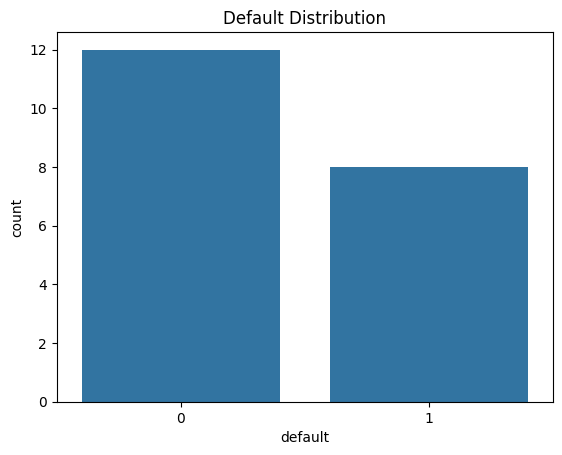

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

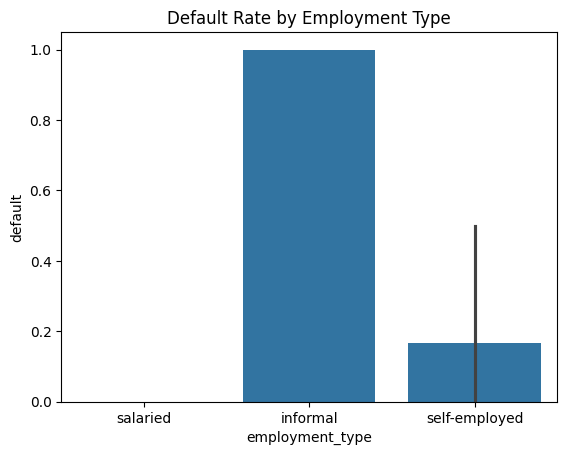

In [10]:
sns.barplot(x='employment_type', y='default', data=df)
plt.title("Default Rate by Employment Type")
plt.show()

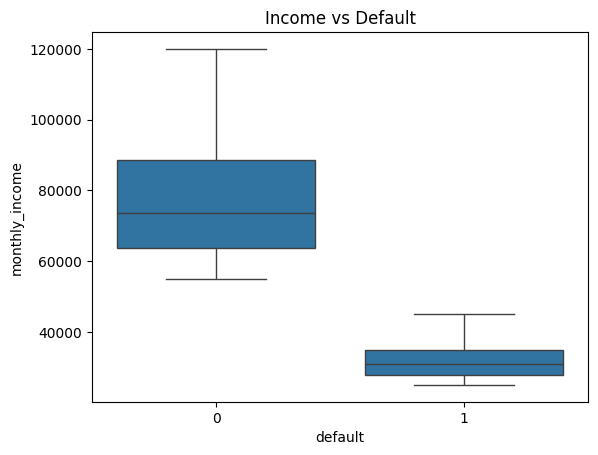

In [11]:
sns.boxplot(x='default', y='monthly_income', data=df)
plt.title("Income vs Default")
plt.show()

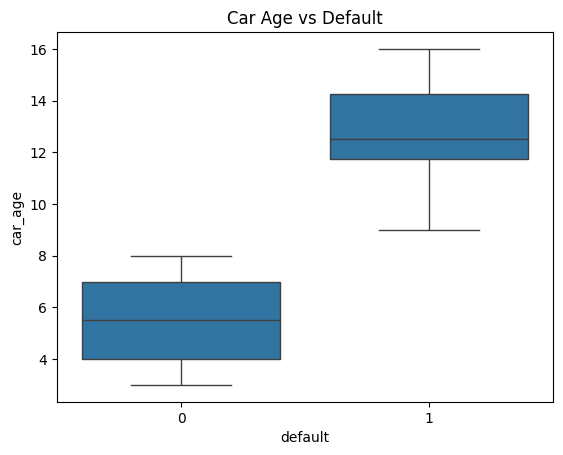

In [12]:
sns.boxplot(x='default', y='car_age', data=df)
plt.title("Car Age vs Default")
plt.show()

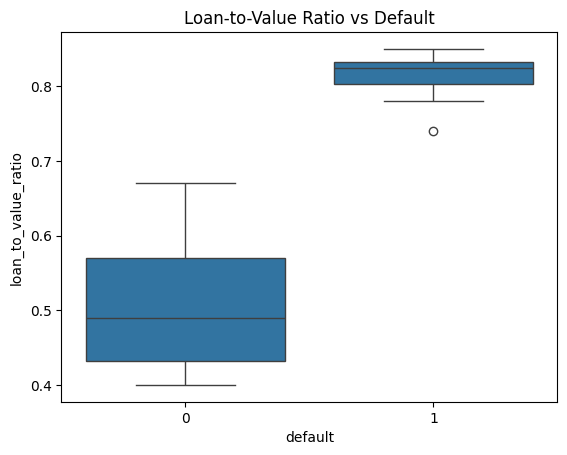

In [16]:
sns.boxplot(x='default', y='loan_to_value_ratio', data=df)
plt.title("Loan-to-Value Ratio vs Default")
plt.show()

## 📌 Key Insights

- Lower income customers are more likely to default  
- Informal employment has higher risk  
- Older vehicles increase default risk  
- High loan-to-value ratio strongly increases default  

# 🤖 Machine Learning Model

## 🎯 Objective
Build a model to predict loan default risk.

In [18]:
# Separate features and target
X = df.drop('default', axis=1)
y = df['default']

In [19]:
# Convert categorical data to numeric
X = pd.get_dummies(X, drop_first=True)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [26]:
confusion_matrix(y_test, y_pred)

array([[1, 0],
       [0, 3]])

## 📊 Model Insights

- The model predicts whether a customer will default or not  
- Accuracy shows overall performance  
- Precision and recall help evaluate risk detection  
- This model can assist lenders in making better decisions  

# 🌲 Advanced Model: Random Forest

## 🎯 Objective
Improve prediction accuracy using a more powerful model.

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
rf_pred = rf_model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 1.0


In [31]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [32]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0


In [33]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
7,mileage,0.180000
9,previous_defaults,0.130000
5,car_value,0.122286
1,monthly_income,0.113056
3,interest_rate,0.110000
6,car_age,0.110000
11,income_to_loan_ratio,0.100000
10,loan_to_value_ratio,0.090000
2,loan_amount,0.027714
8,previous_loans,0.014444


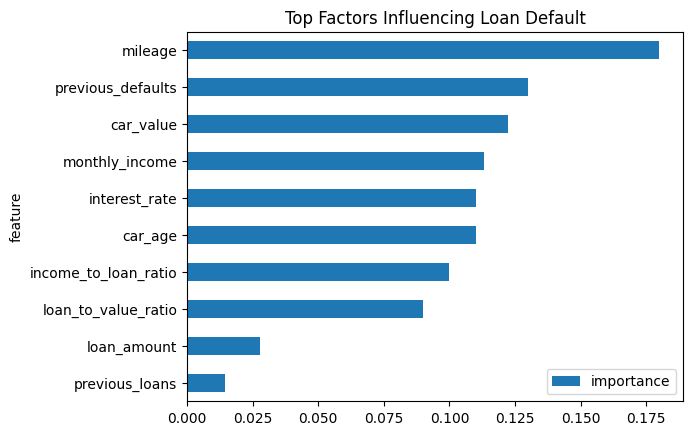

In [34]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    kind='barh',
    x='feature',
    y='importance'
)

plt.title("Top Factors Influencing Loan Default")
plt.gca().invert_yaxis()
plt.show()